# M1.Ex3: Iris Classification

- Run: [**Open In Colab**](https://colab.research.google.com/github/HassanAlgoz/B5/blob/main/content/W3/M1/exercises/ex3_class.ipynb)
- Dataset:`sklearn.datasets.load_iris()`

In [1]:
import pandas as pd
import sklearn

![Iris Flowers](../assets/iris_flowers.png)

### Step 1.a Load the data

In [2]:
iris = sklearn.datasets.load_iris(as_frame=True)

In [6]:
iris.data.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


### Step 2.a Assign variables `X` to the features and `y` to the target

In [3]:
X = iris.data
y = iris.target

### Step 2.b print the type of each

In [4]:
print(type(X))
print(type(y))

<class 'pandas.DataFrame'>
<class 'pandas.Series'>


### Step 2.c identify whether the target is categorical or numerical & whether the task is regression or classification

In [7]:
from pandas.api.types import is_numeric_dtype

if is_numeric_dtype(y) and y.nunique() > 10:
    target_type = "Numerical"
    ml_task = "Regression"
else:
    target_type = "Categorical"
    ml_task = "Classification"

print(f"Target type: {target_type}")
print(f"Machine Learning Task: {ml_task}")

Target type: Categorical
Machine Learning Task: Classification


### Step 3. Identify the number of samples and columns of both the data matrix and the target

In [8]:
n_samples, n_features = X.shape

print(f"X -> Number of samples: {n_samples}")
print(f"X -> Number of columns: {n_features}")

print(f"y -> Number of samples: {y.shape[0]}")
print("y -> Number of columns: 1")

X -> Number of samples: 150
X -> Number of columns: 4
y -> Number of samples: 150
y -> Number of columns: 1


### Step 4. Summarize the distribution of the data (min, max, median, mean, and standard deviation)

In [10]:
for col in X.columns:
    print(f"\nFeature: {col}")
    print(f"Min: {X[col].min()}")
    print(f"Max: {X[col].max()}")
    print(f"Median: {X[col].median()}")
    print(f"Mean: {X[col].mean()}")
    print(f"Std: {X[col].std()}")


Feature: sepal length (cm)
Min: 4.3
Max: 7.9
Median: 5.8
Mean: 5.843333333333334
Std: 0.828066127977863

Feature: sepal width (cm)
Min: 2.0
Max: 4.4
Median: 3.0
Mean: 3.0573333333333337
Std: 0.4358662849366982

Feature: petal length (cm)
Min: 1.0
Max: 6.9
Median: 4.35
Mean: 3.7580000000000005
Std: 1.7652982332594662

Feature: petal width (cm)
Min: 0.1
Max: 2.5
Median: 1.3
Mean: 1.1993333333333336
Std: 0.7622376689603465


### Step 5. Plot the features to identify separability. Can you see clearly distinguishable groups of points?

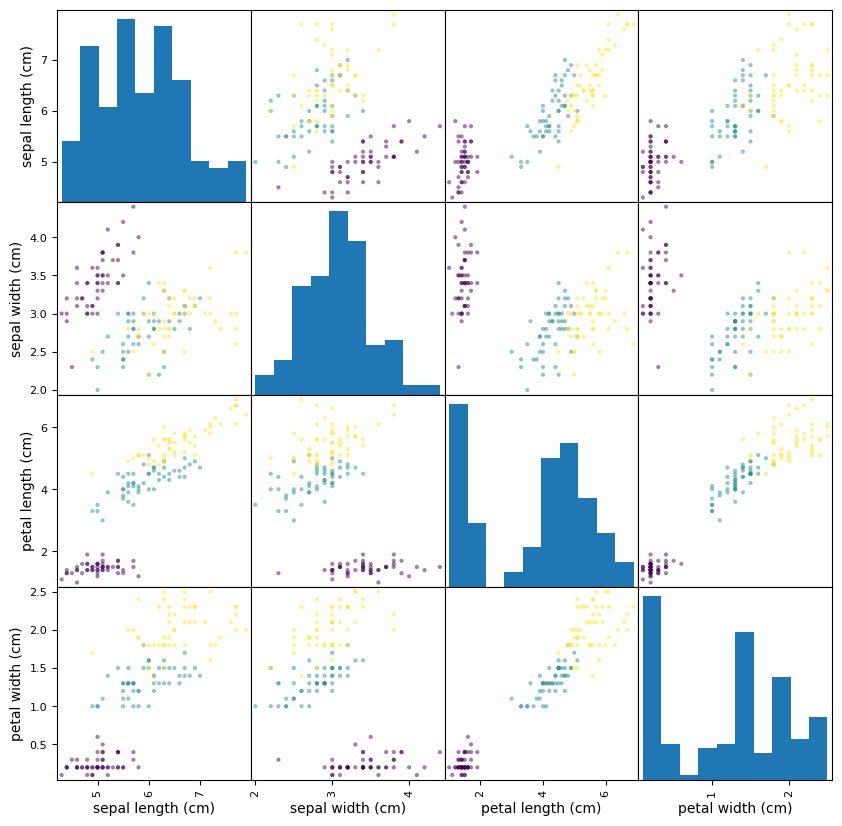

In [11]:
import matplotlib.pyplot as plt
pd.plotting.scatter_matrix(X, figsize=(10, 10), c=y, diagonal='hist')
plt.show()

### Step 6. Keep the following in "Steps 7" onwards

1. First model will trian on the features: `sepal length (cm)` & `sepal width (cm)`
2. Second model will train on the features: `petal length (cm)` & `petal width (cm)`

Finally, evaluate and compare which of the two feature-sets scored better.

Let's do both subsets now..

### Step 6.a subset the features `sepal length (cm)` & `sepal width (cm)`


In [12]:
X_sepal = X[['sepal length (cm)', 'sepal width (cm)']]

### Step 6.b subset the features `petal length (cm)` & `petal width (cm)`


In [13]:
X_petal = X[['petal length (cm)', 'petal width (cm)']]

### Step 7. Initialize 2 `LogisticRegression` models

In [14]:
from sklearn.linear_model import LogisticRegression

model_sepal = LogisticRegression()
model_petal = LogisticRegression()

### Step 8. Split the dataset into train and test sets (remember to stratify by the target to account for class imbalance)

In [15]:
from sklearn.model_selection import train_test_split

train_idx, test_idx = train_test_split(
    X.index,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_sepal_train = X_sepal.loc[train_idx]
X_sepal_test  = X_sepal.loc[test_idx]

X_petal_train = X_petal.loc[train_idx]
X_petal_test  = X_petal.loc[test_idx]

y_train = y.loc[train_idx]
y_test  = y.loc[test_idx]

### Step 9.a Train both models

In [16]:
model_sepal.fit(X_sepal_train, y_train)
model_petal.fit(X_petal_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

### Step 10. Evaluate and compare both models

In [17]:
from sklearn.metrics import accuracy_score

y_pred_sepal = model_sepal.predict(X_sepal_test)
y_pred_petal = model_petal.predict(X_petal_test)

acc_sepal = accuracy_score(y_test, y_pred_sepal)
acc_petal = accuracy_score(y_test, y_pred_petal)

print(f"Sepal model accuracy: {acc_sepal:.4f}")
print(f"Petal model accuracy: {acc_petal:.4f}")

if acc_sepal > acc_petal:
    print("The sepal-features model performed better.")
elif acc_petal > acc_sepal:
    print("The petal-features model performed better.")
else:
    print("Both models performed equally.")

Sepal model accuracy: 0.7333
Petal model accuracy: 0.9667
The petal-features model performed better.


### Step 11. Which of the two subset of features better distinguishes iris flowers? Can you easily tell?

In [18]:
if acc_petal > acc_sepal:
    print("The petal subset better distinguishes iris flowers.")
    print("Yes, it is easier to tell because petal features separate the classes more clearly.")
elif acc_sepal > acc_petal:
    print("The sepal subset better distinguishes iris flowers.")
    print("Yes, but usually petal features are easier to separate visually.")
else:
    print("Both subsets distinguish iris flowers equally well.")

The petal subset better distinguishes iris flowers.
Yes, it is easier to tell because petal features separate the classes more clearly.


### Step 12. Use `DecisionBoundaryDisplay` to plot the learned decision boundary

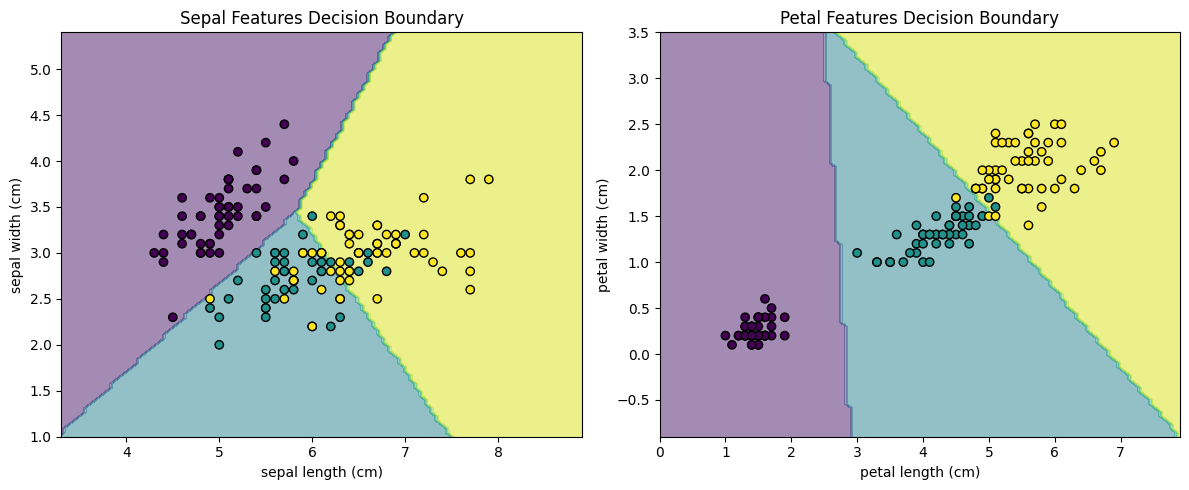

In [19]:
from sklearn.inspection import DecisionBoundaryDisplay
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Sepal model
DecisionBoundaryDisplay.from_estimator(
    model_sepal,
    X_sepal,
    response_method="predict",
    ax=axes[0],
    alpha=0.5
)
axes[0].scatter(X_sepal.iloc[:, 0], X_sepal.iloc[:, 1], c=y, edgecolor="k")
axes[0].set_title("Sepal Features Decision Boundary")
axes[0].set_xlabel(X_sepal.columns[0])
axes[0].set_ylabel(X_sepal.columns[1])

# Petal model
DecisionBoundaryDisplay.from_estimator(
    model_petal,
    X_petal,
    response_method="predict",
    ax=axes[1],
    alpha=0.5
)
axes[1].scatter(X_petal.iloc[:, 0], X_petal.iloc[:, 1], c=y, edgecolor="k")
axes[1].set_title("Petal Features Decision Boundary")
axes[1].set_xlabel(X_petal.columns[0])
axes[1].set_ylabel(X_petal.columns[1])

plt.tight_layout()
plt.show()